In [ ]:
%matplotlib inline

## Utility functions for visualization

In [ ]:
# Below functions are used to visualize the grid data in a more human-readable format
# imported from skeleton/utils.py

from pathlib import Path

import numpy as np

from rich.console import Console
from rich.text import Text
from typing import List

color_map = {
    0: "black",
    1: "red",
    2: "green",
    3: "yellow",
    4: "blue",
    5: "magenta",
    6: "cyan",
    7: "white",
    8: "bright_red",
    9: "bright_green",
}

console = Console(force_jupyter=True)

def make_rich_lines(grid: List[List[int]]) -> List[Text]:
    lines = []
    for row in grid:
        visual = Text()
        for cell in row:
            color = color_map.get(cell, "white")
            visual.append("  ", style=f"on {color}")
        raw = Text("  " + str(row))
        visual.append(raw)
        lines.append(visual)
    return lines

def render_grid(grid: List[List[int]]):
    lines = make_rich_lines(grid)
    console.print(Text("\n").join(lines)) # updated to print lines sequentially in Jupyter


## Create solver instance

In [ ]:
import os

from transformers import set_seed
import json
import pandas as pd
import numpy as np

In [ ]:
token = os.environ.get("HF_TOKEN", None)
from arc import ARCSolver

solver = ARCSolver(token=token)

set_seed(1234567890)

[2025-05-06 09:30:06,725] [INFO] [real_accelerator.py:239:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/home/student/.conda/envs/project/compiler_compat/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/home/student/.conda/envs/project/compiler_compat/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status


ValueError: Some modules are dispatched on the CPU or the disk. Make sure you have enough GPU RAM to fit the quantized model. If you want to dispatch the model on the CPU or the disk while keeping these modules in 32-bit, you need to set `llm_int8_enable_fp32_cpu_offload=True` and pass a custom `device_map` to `from_pretrained`. Check https://huggingface.co/docs/transformers/main/en/main_classes/quantization#offload-between-cpu-and-gpu for more details. 

In [ ]:
def predict(self, examples, questions_input):
    """
    A single example of test data is given.
    You should predict 2D grid (List[List[int]] or np.ndarray)

    Args:
        examples (List[dict]): List of training examples,
            each list element is a dictionary that contains "input" and "output"
            for example,
            [
                {
                    "input": [[1,2],[3,4]],
                    "output": [[4,5],[6,7]],
                },
                {
                    "input": [[0,1],[2,3]],
                    "output": [[3,4],[5,6]],
                }
            ]
        questions_input (List[List[int]]): A 2d grid,
            which is a input for a given question
    Returns:
        output (List[List[int]]): A 2d grid,
            which is the output of given input question.
    """
    datapoint = {
        "train": examples,
        "test": [
            {
                "input": questions_input
            }
        ]
    }

    prompt = self.format_prompt(datapoint)
    input_ids = torch.tensor(prompt['input_ids'], dtype=torch.long).to(self.device).view(1, -1)

    config = GenerationConfig(
        do_sample=False,
        pad_token_id=self.tokenizer.eos_token_id,
        max_new_tokens=150,
    )

    output = self.model.generate(
        input_ids=input_ids,
        generation_config=config,
    ).squeeze().cpu()
    # N_prompt = input_ids.numel()

    # output = output[N_prompt:].tolist()
    # train_input = np.array(prompt['train'][0]['input'])
    # train_output = np.array(prompt['train'][0]['output'])
    # test_input = np.array(prompt['input'])

    # # LLM-generated grid may have wrong shape
    # # So adjust shape by input-output pairs
    # if train_input.shape == train_output.shape:
    #     x, y = test_input.shape
    # else:
    #     x = (train_output.shape[0] // train_input.shape[0]) * test_input.shape[0]
    #     y = (train_output.shape[1] // train_input.shape[1]) * test_input.shape[1]

    # try:
    #     grid = np.array(self.parse_grid(output))
    #     grid = grid[:x, :y]
        
    # except Exception as e:
    #     grid = np.random.randint(0, 10, (x, y))

    return output

def load_data(base_dir):
    filenames = os.listdir(base_dir)
    data_files = [os.path.join(base_dir, p) for p in filenames if ".json" in p]

    dataset = []
    for fn in data_files:
        with open(fn) as fp:
            data = json.load(fp)
        dataset.append(data)

    filenames = [fn.split(".")[0] for fn in filenames]
    data = []
    MAX_LEN = 1000
    rng = np.random.default_rng(42)

    N = len(dataset)

    while len(data) < MAX_LEN:
        task_idx = rng.integers(0, N)
        task = dataset[task_idx]
        file_name = filenames[task_idx]

        n_task = len(task)
        grids_idx =  rng.choice(n_task, size=4, replace=True)
        train_grids = [task[i] for i in grids_idx[:3]]
        test_grids = [task[i] for i in grids_idx[3:]]

        test_inputs = [{'input': grid['input']} for grid in test_grids]
        test_outputs = [grid['output'] for grid in test_grids]
        test_outputs_transformed = [{'output': grid} for grid in test_outputs]
        combined_tests = []
        for test_input, test_output in zip(test_inputs, test_outputs_transformed):
            combined_tests.append({'input': test_input['input'], 'output': test_output['output']})

        data.append({
            'task': file_name,
            'train': train_grids,
            'test_input': test_inputs,
            'test_output': test_outputs,
            'test': combined_tests,
        })

    df = pd.DataFrame(data)
    return df

In [ ]:
import random
from datasets import Dataset

solver.prepare_evaluation()

data_path = "/workspace/dataset"
df = load_data(data_path)

eval_dataset = Dataset.from_pandas(df).shuffle(42).select(range(N_data))
eval_data = random.choice(eval_dataset)
preds = predict(
    eval_data["train"],
    eval_data["test"][0]["input"],
)

print(preds)

## EDA

In [ ]:
dataset.head()

Below is the visualization code for each task. You may visualize the task you want by setting `task_idx` as you like.

In [ ]:
task_idx = 999

print(f"[Task #{task_idx} ({dataset['task'][task_idx]}) in dataset]\n")

print("train example #0")
render_grid(dataset['train'][task_idx][0]['input'])
render_grid(dataset['train'][task_idx][0]['output'])

print("train example #1")
render_grid(dataset['train'][task_idx][1]['input'])
render_grid(dataset['train'][task_idx][1]['output'])

print("train example #2")
render_grid(df['train'][task_idx][2]['input'])
render_grid(df['train'][task_idx][2]['output'])

print("test input")
render_grid(df['test_input'][task_idx][0]['input'])

print("test output")
render_grid(df['test_output'][task_idx][0])

## Dataset

`Dataset.from_pandas` function converts the pandas dataframe above into the huggingface dataset. Unlike `df`, `dataset` is an array so that we may iteratively address each data.

In [32]:
from datasets import Dataset
dataset = Dataset.from_pandas(df).shuffle(42)
dataset

Dataset({
    features: ['task', 'train', 'test_input', 'test_output', 'test'],
    num_rows: 1000
})

Note the position of `task_idx`.

In [33]:
task_idx = 999

print(f"[Task #{task_idx} ({dataset[task_idx]['task']}) in dataset]\n")

print("train example #0")
render_grid(dataset[task_idx]['train'][0]['input'])
render_grid(dataset[task_idx]['train'][0]['output'])

print("train example #1")
render_grid(dataset[task_idx]['train'][1]['input'])
render_grid(dataset[task_idx]['train'][1]['output'])

print("train example #2")
render_grid(dataset[task_idx]['train'][2]['input'])
render_grid(dataset[task_idx]['train'][2]['output'])

print("test input")
render_grid(dataset[task_idx]['test_input'][0]['input'])
# or
# render_grid(dataset[task_idx]['test'][0]['input'])

print("test output")
render_grid(dataset[task_idx]['test_output'][0])
# or
# render_grid(dataset[task_idx]['test'][0]['output'])

[Task #999 (67a423a3) in dataset]

train example #0


                  [7, 8, 7, 7, 7, 7, 7, 7]
                  [0, 8, 0, 0, 0, 0, 0, 0]
                  [0, 8, 0, 0, 0, 0, 0, 0]
                  [7, 8, 7, 7, 7, 7, 7, 7]
                  [7, 8, 7, 7, 7, 7, 7, 7]
                  [7, 8, 7, 7, 7, 7, 7, 7]
                  [7, 8, 7, 7, 7, 7, 7, 7]

                  [4, 4, 4, 7, 7, 7, 7, 7]
                  [4, 8, 4, 0, 0, 0, 0, 0]
                  [4, 8, 4, 0, 0, 0, 0, 0]
                  [4, 4, 4, 7, 7, 7, 7, 7]
                  [7, 8, 7, 7, 7, 7, 7, 7]
                  [7, 8, 7, 7, 7, 7, 7, 7]
                  [7, 8, 7, 7, 7, 7, 7, 7]

train example #1


                [3, 3, 7, 7, 3, 3, 3]
                [3, 3, 7, 7, 3, 3, 3]
                [3, 3, 7, 7, 3, 3, 3]
                [5, 5, 7, 7, 5, 5, 5]
                [3, 3, 7, 7, 3, 3, 3]
                [3, 3, 7, 7, 3, 3, 3]
                [3, 3, 7, 7, 3, 3, 3]
                [3, 3, 7, 7, 3, 3, 3]

...

              [9, 9, 9, 7, 7, 9]
              [9, 9, 9, 7, 7, 9]
              [9, 9, 9, 7, 7, 9]
              [9, 9, 4, 4, 4, 4]
              [2, 2, 4, 7, 7, 4]
              [2, 2, 4, 7, 7, 4]
              [9, 9, 4, 4, 4, 4]
              [9, 9, 9, 7, 7, 9]
              [9, 9, 9, 7, 7, 9]

test input


                      [0, 0, 0, 0, 0, 8, 8, 0, 0, 0]
                      [7, 7, 7, 7, 7, 8, 8, 7, 7, 7]
                      [0, 0, 0, 0, 0, 8, 8, 0, 0, 0]
                      [0, 0, 0, 0, 0, 8, 8, 0, 0, 0]
                      [0, 0, 0, 0, 0, 8, 8, 0, 0, 0]
                      [0, 0, 0, 0, 0, 8, 8, 0, 0, 0]
                      [0, 0, 0, 0, 0, 8, 8, 0, 0, 0]

test output


                      [0, 0, 0, 0, 4, 4, 4, 4, 0, 0]
                      [7, 7, 7, 7, 4, 8, 8, 4, 7, 7]
                      [0, 0, 0, 0, 4, 4, 4, 4, 0, 0]
                      [0, 0, 0, 0, 0, 8, 8, 0, 0, 0]
                      [0, 0, 0, 0, 0, 8, 8, 0, 0, 0]
                      [0, 0, 0, 0, 0, 8, 8, 0, 0, 0]
                      [0, 0, 0, 0, 0, 8, 8, 0, 0, 0]

In [34]:
train_val_split = dataset.train_test_split(test_size=0.1, seed=42)

In [35]:
train_dataset = train_val_split['train']
train_dataset

Dataset({
    features: ['task', 'train', 'test_input', 'test_output', 'test'],
    num_rows: 900
})

In [36]:
val_dataset = train_val_split['test']
val_dataset

Dataset({
    features: ['task', 'train', 'test_input', 'test_output', 'test'],
    num_rows: 100
})

## Format Dataset

In [4]:
import os

from transformers import set_seed
import json
import pandas as pd
import numpy as np

In [5]:
def load_data(base_dir):
    '''
    Load data from the specified directory and return a DataFrame.
    '''

    filenames = os.listdir(base_dir) # 파일명에 확장자 포함
    data_files = [os.path.join(base_dir, p) for p in filenames if ".json" in p]

    dataset = []
    for fn in data_files:
        with open(fn) as fp:
            data = json.load(fp)
        dataset.append(data)

    filenames = [fn.split(".")[0] for fn in filenames] # 확장자 제거
    data = []
    MAX_LEN = 1000 # train dataset의 최대 길이. 필요에 따라 조정 가능
    rng = np.random.default_rng(42)

    N = len(dataset)

    while len(data) < MAX_LEN:
        task_idx = rng.integers(0, N) # 랜덤으로 task 선택
        task = dataset[task_idx]
        file_name = filenames[task_idx]

        n_task = len(task)
        grids_idx =  rng.choice(n_task, size=4, replace=True) # 앞서 추출한 task에서 랜덤으로 4개의 grid 선택
        train_grids = [task[i] for i in grids_idx[:3]] # 3개는 train data로 사용
        test_grids = [task[i] for i in grids_idx[3:]] # 1개는 test data로 사용

        test_inputs = [{'input': grid['input']} for grid in test_grids]
        test_outputs = [grid['output'] for grid in test_grids]
        test_outputs_transformed = [{'output': grid} for grid in test_outputs]
        combined_tests = []
        for test_input, test_output in zip(test_inputs, test_outputs_transformed):
            combined_tests.append({'input': test_input['input'], 'output': test_output['output']})

        data.append({
            'task': file_name,
            'train': train_grids,
            'test_input': test_inputs,
            'test_output': test_outputs,
            'test': combined_tests,
        })

    df = pd.DataFrame(data)
    return df

In [6]:
N_data = 4
data_path = "/workspace/dataset"
df = load_data(data_path)

from datasets import Dataset
dataset = Dataset.from_pandas(df).shuffle(42)

In [7]:
train_val_split = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = train_val_split['train']
val_dataset = train_val_split['test']

In [8]:
train_dataset = train_dataset.map(
                    lambda x: solver.format_prompt(x, is_train=True),
                    remove_columns=train_dataset.column_names,
                )

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

In [9]:
val_dataset = val_dataset.map(
                    lambda x: solver.format_prompt(x, is_train=False),
                    remove_columns=val_dataset.column_names,
                )

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [10]:
dataset

Dataset({
    features: ['task', 'train', 'test_input', 'test_output', 'test'],
    num_rows: 1000
})

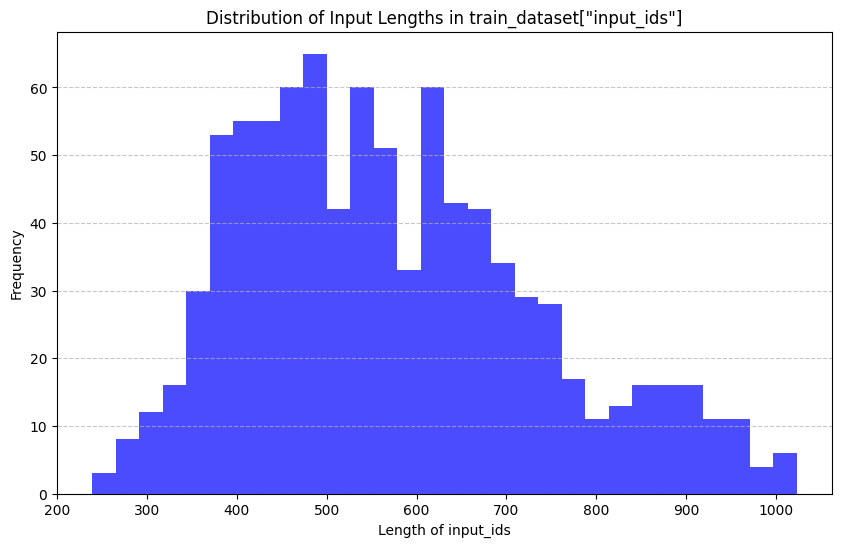

In [15]:
import matplotlib.pyplot as plt

# Calculate the lengths of input_ids
input_lengths = [len(input_id) for input_id in train_dataset['input_ids']]

# Plot the lengths
plt.figure(figsize=(10, 6))
plt.hist(input_lengths, bins=30, color='blue', alpha=0.7)
plt.title('Distribution of Input Lengths in train_dataset["input_ids"]')
plt.xlabel('Length of input_ids')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig("plot.png")  # Save the plot to a file

In [12]:
val_dataset[0].keys()

dict_keys(['input_ids', 'attention_mask'])

In [13]:
from trl import SFTConfig, SFTTrainer, DataCollatorForCompletionOnlyLM
data_collator = DataCollatorForCompletionOnlyLM(
    tokenizer=solver.tokenizer,
    instruction_template='<|start_header_id|>user<|end_header_id|>',
    response_template='<|start_header_id|>assistant<|end_header_id|>',
)

/home/student/workspace/venv/lib/python3.11/site-packages/trl/trainer/utils.py:123: UserWarning: The pad_token_id and eos_token_id values of this tokenizer are identical. If you are planning for multi-turn training, it can result in the model continuously generating questions and answers without eos token. To avoid this, set the pad_token_id to a different value.
  warnings.warn(
